In [26]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import joblib
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\\Users\\hsoopa\\Desktop\New folder (3)\\IMDB Dataset.csv')

In [3]:
df 

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [11]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [17]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text) 
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower() 
    return text

In [18]:
df['clean_review'] = df['review'].apply(clean_text)

In [20]:
df['clean_review'][120]

'this movie gets a    because there is a lot of gore in it who cares about the plot or the acting this is an italian horror movie people so you know you can t expect much from the acting or the plot everybody knows fulci took footage from other movies and added it to this one since i never seen any of the movies that he took footage from it didn t matter to me the italian godfather of gore out done himself with this movie this is one of the goriest italian movies you will ever see no gore hound should be without this movie in their horror movie collection buy this movie no matter what it is a horehounds dream come true '

In [21]:
df['review'][120]

"this movie gets a 10 because there is a lot of gore in it.who cares about the plot or the acting.this is an Italian horror movie people so you know you can't expect much from the acting or the plot.everybody knows fulci took footage from other movies and added it to this one.since i never seen any of the movies that he took footage from it didn't matter to me.the Italian godfather of gore out done himself with this movie.this is one of the goriest Italian movies you will ever see.no gore hound should be without this movie in their horror movie collection.buy this movie no matter what it is a horehounds dream come true."

In [22]:
X = df['clean_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [36]:
model = LinearSVC()
model.fit(X_train_vec, y_train)

LinearSVC()

In [37]:
predictions = model.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")

Accuracy: 0.89


In [38]:
print("Classification Report:\n")
print(classification_report(y_test, predictions))

Classification Report:

              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000




Confusion Matrix:


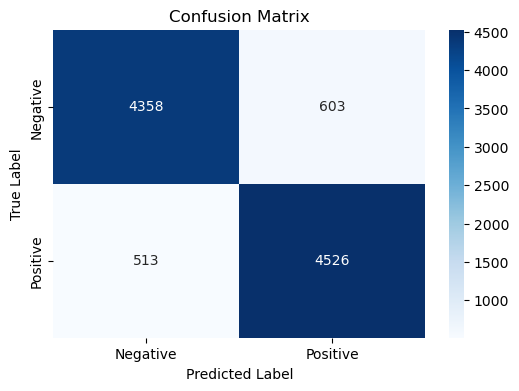

In [39]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [29]:
joblib.dump(model, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']